<a href="https://colab.research.google.com/github/ebritolbv-cmd/BrazilQuantumCamp/blob/main/4_Caix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brazil Quantum Camp

**Bloco 2, Aula 4** Heurísticas e Meta-heurísticas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
import random

In [ ]:
class Instance:
    """Instância do PCV com n cidades, matriz de distâncias D, e coordenadas c."""

    def __init__(self, n):
        self.n = n  # número de cidades
        # coordenadas Euclidianas (2 x n)
        self.c = np.random.rand(2, n)
        # matriz de distâncias (n+1 x n+1 para wrap-around)
        self.D = np.zeros((n + 1, n + 1))
        for i in range(n):
            for j in range(n):
                self.D[i, j] = norm(self.c[:, i] - self.c[:, j])
        # wrap-around: cidade n = cidade 0
        self.D[n, :] = self.D[0, :]
        self.D[:, n] = self.D[:, 0]

    def point(self, i):
        """Retorna coordenadas da cidade i."""
        return self.c[:, i]

In [ ]:
I = Instance(500)
print(I.D)

[[0.         0.29173063 0.50374804 ... 0.39337384 0.7339732  0.        ]
 [0.29173063 0.         0.21208512 ... 0.52561207 0.66964837 0.29173063]
 [0.50374804 0.21208512 0.         ... 0.69054625 0.70645191 0.50374804]
 ...
 [0.39337384 0.52561207 0.69054625 ... 0.         0.4591975  0.39337384]
 [0.7339732  0.66964837 0.70645191 ... 0.4591975  0.         0.7339732 ]
 [0.         0.29173063 0.50374804 ... 0.39337384 0.7339732  0.        ]]


In [ ]:
def draw_instance(I, ax=None):
    """Desenha cidades como gráfico de dispersão."""
    if ax is None:
        ax = plt.gca()
    ax.scatter(I.c[0, :], I.c[1, :], c='black', s=10)
    ax.set_aspect('equal')
    return ax

def draw_solution(I, s, ax=None):
    """Desenha arestas do tour."""
    if ax is None:
        ax = plt.gca()
    for i in range(I.n):
        x = [I.c[0, s.pi[i]], I.c[0, s.pi[i + 1]]]
        y = [I.c[1, s.pi[i]], I.c[1, s.pi[i + 1]]]
        ax.plot(x, y, c='gray', linewidth=0.5)
    return ax

def draw_both(I, s, figsize=(6, 6)):
    """Desenha instância e solução juntas."""
    fig, ax = plt.subplots(figsize=figsize)
    draw_solution(I, s, ax)
    draw_instance(I, ax)
    plt.show()
    return fig, ax

In [ ]:
class Solution:
    """Solução do PCV: uma permutação de cidades e seu valor objetivo."""

    def __init__(self, pi, v):
        self.pi = list(pi)  # permutação (tour)
        self.v = v          # valor objetivo (distância total)

    def copy(self):
        """Retorna uma cópia desta solução."""
        return Solution(self.pi, self.v)

## Heurística construtiva: vizinho mais próximo

In [ ]:
def vmp(I):
    """Heurística do vizinho mais próximo."""
    s = Solution([0], 0.0)  # começa na cidade 0
    free = [True] * I.n
    free[0] = False

    for _ in range(1, I.n):
        # encontra cidades livres
        candidates = [j for j in range(I.n) if free[j]]
        # encontra cidade livre mais próxima
        last = s.pi[-1]
        distances = [I.D[last, j] for j in candidates]
        best_idx = np.argmin(distances)
        j = candidates[best_idx]
        # adiciona ao tour
        s.v += I.D[last, j]
        s.pi.append(j)
        free[j] = False

    # retorna ao início
    s.v += I.D[s.pi[-1], 0]
    s.pi.append(0)

    return s

In [ ]:
s = vmp(I)
print(f"Vizinho mais próximo: {s.v}")

Vizinho mais próximo: 20.75621654942818


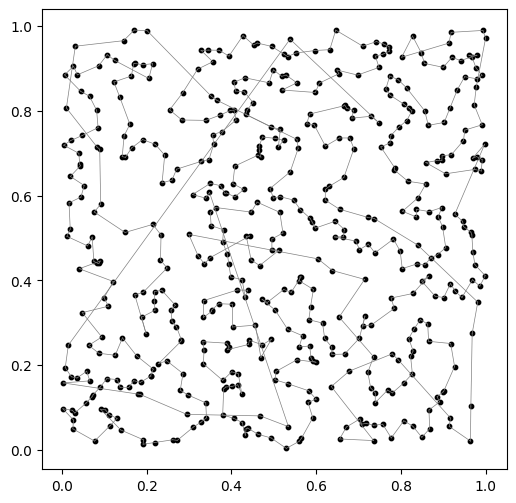

(<Figure size 600x600 with 1 Axes>, <Axes: >)

In [ ]:
draw_both(I, s)

## Busca local: troca de cidades adjacentes (tca)

Tem $n$ possíveis trocas de cidades adjacentes, logo um movimento é representado por um índice $0 \leq i < n$ que corresponde com a troca das cidades $i$ e $i + 1$ (modulo n).

In [ ]:
def delta_tca(I, s, i):
    """Variação da função objetivo ao aplicar troca adjacente na posição i."""
    # cidades: h, i, j, k
    h = i - 1 if i > 0 else I.n - 1
    j = i + 1
    k = i + 2 if i < I.n - 1 else 0
    return (-I.D[s.pi[h], s.pi[i]] - I.D[s.pi[j], s.pi[k]]
            + I.D[s.pi[h], s.pi[j]] + I.D[s.pi[i], s.pi[k]])

def random_tca(n):
    """Seleciona um movimento de troca adjacente aleatoriamente."""
    return np.random.randint(0, n)

def move_tca(I, s, i):
    """Aplica troca adjacente na posição i."""
    s.v += delta_tca(I, s, i)
    s.pi[i], s.pi[i + 1] = s.pi[i + 1], s.pi[i]
    s.pi[I.n] = s.pi[0]  # atualiza wrap-around
    return s

In [ ]:
def bl_tca(I, s0):
    """Busca local com primeira melhoria usando trocas adjacentes."""
    s = s0.copy()
    while True:
        m = -1
        for i in range(I.n):
            delta = delta_tca(I, s, i)
            if delta < 0:
                m = i
                break  # primeira melhoria
        if m < 0:
            break
        move_tca(I, s, m)
    return s

In [ ]:
s_tca = bl_tca(I, s)
print("Busca local, troca de cidades adjacentes:")
print(f"Antes  : {s.v:.3f}")
print(f"Depois : {s_tca.v:.3f}")

Busca local, troca de cidades adjacentes:
Antes  : 20.756
Depois : 20.437


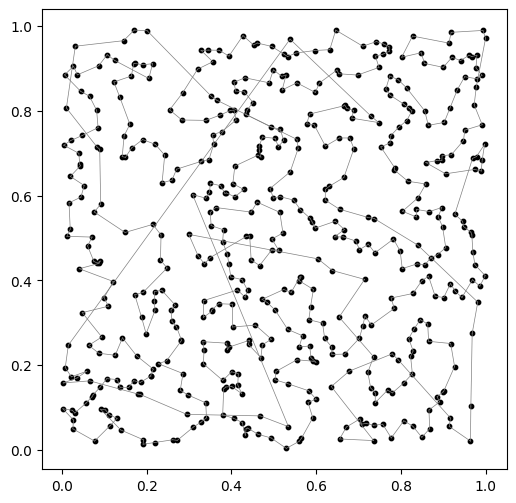

(<Figure size 600x600 with 1 Axes>, <Axes: >)

In [ ]:
draw_both(I, s_tca)

## Busca local: 2-opt (com movimentos 2-exchange)

Funções para trabalhar com movimentos $2$-opt. Um movimento é um par $(i,j)$ e corresponde com arcos $(i,i+1)$ e $(j,j+1)$. Como as arestas não podem ser adjacentes, temos os $\binom{n}{2}$ seleções de duas arestas menos os $n$ pares de arestas adjacentes, logo $\binom{n}{2}-n$ vizinhos.

In [ ]:
from math import comb

def twoex_size(n):
    """Número de movimentos 2-exchange."""
    return comb(n, 2) - n

def delta_2ex(I, s, move):
    """Variação da função objetivo ao aplicar movimento 2-exchange."""
    a, b = move
    return (-I.D[s.pi[a], s.pi[a + 1]] - I.D[s.pi[b], s.pi[b + 1]]
            + I.D[s.pi[a], s.pi[b]] + I.D[s.pi[a + 1], s.pi[b + 1]])

def twoex_unrank(n, r):
    """Retorna o r-ésimo movimento 2-exchange (0 <= r < twoex_size(n))."""
    d = 2 + r // n
    a = r % n
    b = (a + d) % n
    if b > a:
        a, b = b, a
    return (a, b)

def random_twoex(n):
    """Seleciona um movimento 2-exchange aleatoriamente."""
    return twoex_unrank(n, np.random.randint(0, twoex_size(n)))

def move_2ex(I, s, move):
    """Aplica movimento 2-exchange (inverte segmento)."""
    s.v += delta_2ex(I, s, move)
    a, b = move
    if a > b:
        a, b = b, a
    a += 1
    # inverte segmento [a, b]
    while a < b:
        s.pi[a], s.pi[b] = s.pi[b], s.pi[a]
        a += 1
        b -= 1
    s.pi[I.n] = s.pi[0]  # atualiza wrap-around
    return s

In [ ]:
def bl_2ex(I, s0):
    """Busca local com primeira melhoria usando 2-exchange."""
    s = s0.copy()
    while True:
        move = None
        for r in range(twoex_size(I.n)):
            m = twoex_unrank(I.n, r)
            delta = delta_2ex(I, s, m)
            if delta < -1e-9:
                move = m
                break  # primeira melhoria
        if move is None:
            break
        move_2ex(I, s, move)
    return s

In [ ]:
s_2ex = bl_2ex(I, s)
print("Busca local, 2-exchange:")
print(f"Antes  : {s.v:.3f}")
print(f"Depois : {s_2ex.v:.3f}")

Busca local, 2-exchange:
Antes  : 20.756
Depois : 17.824


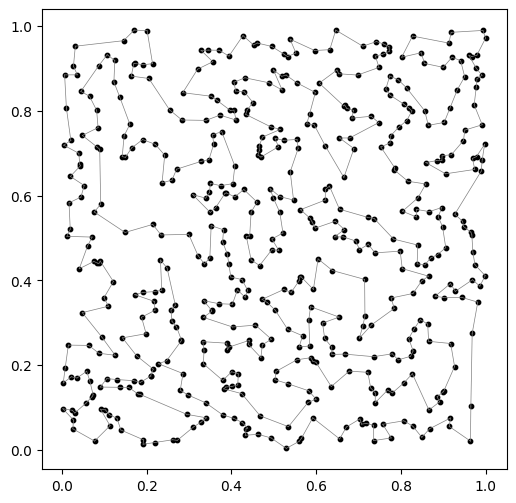

(<Figure size 600x600 with 1 Axes>, <Axes: >)

In [ ]:
draw_both(I, s_2ex)

## Vizinho mais próximo randomizado

In [ ]:
def vmp_rnd(I, k):
    """Heurística do vizinho mais próximo randomizada."""
    s = Solution([0], 0.0)
    free = [True] * I.n
    free[0] = False

    for i in range(1, I.n):
        # encontra cidades livres
        candidates = [j for j in range(I.n) if free[j]]
        # ordena por distância e seleciona aleatoriamente entre os k mais próximos
        last = s.pi[-1]
        sorted_candidates = sorted(candidates, key=lambda j: I.D[last, j])
        ncand = min(k, len(sorted_candidates))
        j = sorted_candidates[np.random.randint(0, ncand)]
        # adiciona ao tour
        s.v += I.D[last, j]
        s.pi.append(j)
        free[j] = False

    # retorna ao início
    s.v += I.D[s.pi[-1], 0]
    s.pi.append(0)

    return s

In [ ]:
s = vmp_rnd(I, 3)
print(f"Vizinho mais próximo randomizado: {s.v:.3f}")

Vizinho mais próximo randomizado: 33.058


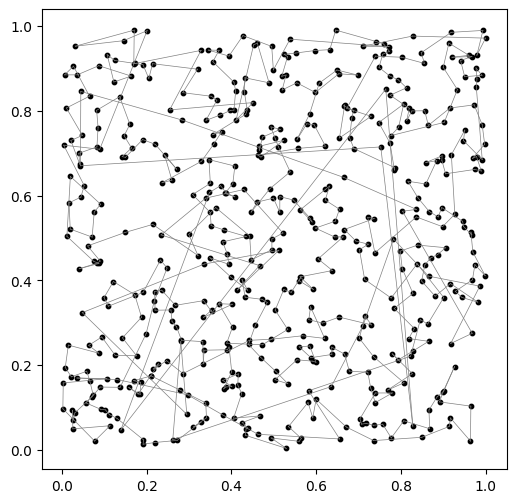

(<Figure size 600x600 with 1 Axes>, <Axes: >)

In [ ]:
draw_both(I, s)

## GRASP
(Cuidado: muito lento, deveria fazer 100 iterações/segundo.)

In [ ]:
def grasp(I):
    """GRASP: construção randomizada + busca local."""
    b = vmp(I)
    i = 1
    ii = 1
    print(f"I {i:2} {i - ii} {b.v:.3f} {b.v:.3f}")

    while i - ii < 50:
        s = vmp_rnd(I, 2)
        s = bl_2ex(I, s)
        if s.v < b.v:
            b = s.copy()
            ii = i
            print(f"* {i:2} {i - ii} {s.v:.3f} {b.v:.3f}")
        else:
            print(f"  {i:2} {i - ii} {s.v:.3f} {b.v:.3f}")
        i += 1

    return b

In [ ]:
b = grasp(I)
print(f"Melhor solução: {b.v:.3f}")

I  1 0 20.756 20.756
*  1 0 18.605 18.605
*  2 0 18.361 18.361
   3 1 18.517 18.361
   4 2 18.449 18.361
   5 3 18.422 18.361
*  6 0 18.305 18.305
*  7 0 18.184 18.184
   8 1 18.904 18.184
   9 2 19.079 18.184
  10 3 18.714 18.184


KeyboardInterrupt: 

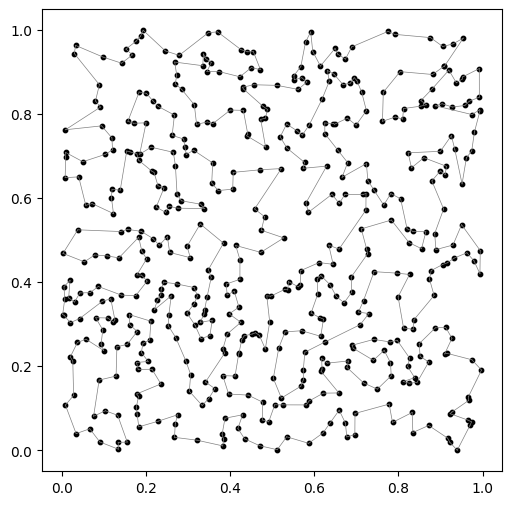

(<Figure size 600x600 with 1 Axes>, <Axes: >)

In [ ]:
draw_both(I, b)

## Tempera simulada

### Algoritmo Metropolis

In [ ]:
def Metropolis(I, s, L, T, best):
    """Algoritmo Metropolis: L iterações na temperatura T."""
    for _ in range(L):
        m = random_twoex(I.n)
        delta = delta_2ex(I, s, m)
        # aceita condicionalmente
        if np.random.rand() < min(np.exp(-delta / T), 1.0):
            move_2ex(I, s, m)
            if s.v < best.v:
                best = s.copy()
    return s, best


def SimulatedAnnealing(I, s, L, r):
    """Tempera simulada com resfriamento geométrico."""
    best = s.copy()
    # (1) define temperatura inicial alta que aceita piorar pela distância média com prob. 1/e
    T = np.mean(I.D)
    # (2) define temperatura final baixa que aceita piorar por 1/10 da distância mínima com prob. 1/e
    min_dist = np.min([I.D[i, j] for i in range(I.n) for j in range(I.n) if i != j])
    Tf = min_dist / 10
    n_iter = int(np.ceil(np.log(Tf / T) / np.log(r)))
    print(f"Temperatura final: {Tf:.6f}, logo {n_iter} iterações.")

    i = 1
    while T > Tf:
        s, best = Metropolis(I, s, L, T, best)
        print(f"{i:3} T={T:.3f} v={s.v:.4f} b={best.v:.3f}")
        T *= r
        i += 1

    return best

In [ ]:
best = SimulatedAnnealing(I, vmp(I).copy(), 10 * twoex_size(I.n), 0.95)

Temperatura final: 0.000108, logo 166 iterações.
  1 T=0.523 v=216.3519 b=20.756
  2 T=0.497 v=200.7762 b=20.756
  3 T=0.472 v=205.4237 b=20.756
  4 T=0.448 v=200.5816 b=20.756
  5 T=0.426 v=199.2941 b=20.756
  6 T=0.405 v=190.3645 b=20.756
  7 T=0.384 v=195.3764 b=20.756
  8 T=0.365 v=191.0642 b=20.756
  9 T=0.347 v=185.3700 b=20.756
 10 T=0.329 v=179.4332 b=20.756
 11 T=0.313 v=175.0295 b=20.756
 12 T=0.297 v=176.9490 b=20.756
 13 T=0.282 v=174.0391 b=20.756
 14 T=0.268 v=160.0250 b=20.756
 15 T=0.255 v=171.1163 b=20.756
 16 T=0.242 v=149.0951 b=20.756
 17 T=0.230 v=154.8388 b=20.756
 18 T=0.219 v=156.0842 b=20.756
 19 T=0.208 v=148.1380 b=20.756
 20 T=0.197 v=144.9204 b=20.756
 21 T=0.187 v=134.6489 b=20.756
 22 T=0.178 v=130.5752 b=20.756
 23 T=0.169 v=130.3612 b=20.756
 24 T=0.161 v=124.9086 b=20.756
 25 T=0.153 v=115.4991 b=20.756
 26 T=0.145 v=113.0239 b=20.756
 27 T=0.138 v=114.6343 b=20.756
 28 T=0.131 v=109.2070 b=20.756
 29 T=0.124 v=98.5217 b=20.756
 30 T=0.118 v=98.0331 b=

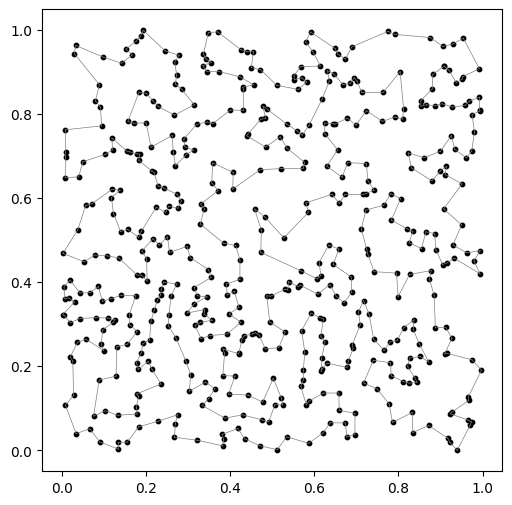

(<Figure size 600x600 with 1 Axes>, <Axes: >)

In [ ]:
draw_both(I, best)

## Busca local iterada

Amostragem de 4 cidades com distância pelo menos um entre eles. Isso é feito por amostragem de rejeição. Vamos selecionar 4 cidades aleatórios entre $1$ e $n-4$, o que tem $\binom{n-4}{4}$ possibilidades, inserer uma distância entre eles, e rejeitar caso não tem distância entre a primeira e última cidade. Um movimento é uma tupla $(m_1,m_2,m_3,m_4)$ de quatro cidades. Por convenção os arcos correspondentes são $(m_i,m_i+1)$.

In [ ]:
def delta_double_bridge(I, s, move):
    """Variação da função objetivo para movimento double bridge."""
    delta = 0
    for i in range(4):
        delta -= I.D[s.pi[move[i]], s.pi[move[i] + 1]]
    for p in [(2, 0), (1, 3), (0, 2), (3, 1)]:
        delta += I.D[s.pi[move[p[0]]], s.pi[move[p[1]] + 1]]
    return delta


def random_double_bridge(n):
    """Seleciona um movimento double bridge aleatório."""
    a = [0, 1, 2, n - 1]
    while a[0] == 0 and a[3] == n - 1:
        # amostra 4 posições ordenadas de 0 a n-5
        a = sorted(random.sample(range(n - 4), 4))
    return (a[0], a[1] + 1, a[2] + 2, a[3] + 3)


def move_double_bridge(I, s, move):
    """Aplica movimento double bridge."""
    s.v += delta_double_bridge(I, s, move)
    # reorganiza os segmentos
    new_pi = (
        s.pi[move[1] + 1 : move[2] + 1]
        + s.pi[move[0] + 1 : move[1] + 1]
        + s.pi[move[3] + 1 :]
        + s.pi[: move[0] + 1]
        + s.pi[move[2] + 1 : move[3] + 1]
    )
    s.pi = new_pi
    return s

### Variante simples

Uma busca local iterada simples. Ela aplica uma perturbação em cada mínimo local.

In [ ]:
def ils(I, s):
    """Busca local iterada simples."""
    best = s.copy()
    s = bl_2ex(I, s)
    i = ii = 1
    print(f"I {i:2} {i - ii:2} {s.v:.3f} {best.v:.3f}")

    while i - ii < 100:
        s = move_double_bridge(I, s, random_double_bridge(I.n))
        s = bl_2ex(I, s)
        if s.v < best.v:
            best = s.copy()
            ii = i
            print(f"* {i:2} {i - ii:2} {s.v:.3f} {best.v:.3f}")
        else:
            print(f"  {i:2} {i - ii:2} {s.v:.3f} {best.v:.3f}")
        i += 1

    return best

In [ ]:
best_ils = ils(I, vmp(I).copy())

I  1  0 17.767 20.744
*  1  0 17.923 17.923
   2  1 18.236 17.923
   3  2 18.326 17.923
   4  3 18.724 17.923
   5  4 18.768 17.923
   6  5 18.603 17.923
   7  6 18.599 17.923
   8  7 18.850 17.923
   9  8 18.773 17.923
  10  9 18.688 17.923
  11 10 18.676 17.923
  12 11 18.455 17.923
  13 12 18.555 17.923
  14 13 18.957 17.923
  15 14 19.053 17.923
  16 15 19.252 17.923
  17 16 19.050 17.923
  18 17 19.537 17.923
  19 18 19.386 17.923
  20 19 19.283 17.923
  21 20 19.061 17.923
  22 21 19.426 17.923
  23 22 19.549 17.923
  24 23 19.017 17.923
  25 24 18.577 17.923
  26 25 18.746 17.923
  27 26 19.100 17.923
  28 27 19.215 17.923
  29 28 18.980 17.923
  30 29 19.407 17.923
  31 30 19.264 17.923
  32 31 19.269 17.923
  33 32 19.464 17.923
  34 33 19.390 17.923
  35 34 19.453 17.923
  36 35 19.246 17.923
  37 36 19.947 17.923
  38 37 19.867 17.923
  39 38 19.899 17.923
  40 39 19.898 17.923
  41 40 19.393 17.923
  42 41 19.517 17.923
  43 42 19.651 17.923
  44 43 19.875 17.923
  45 44 19

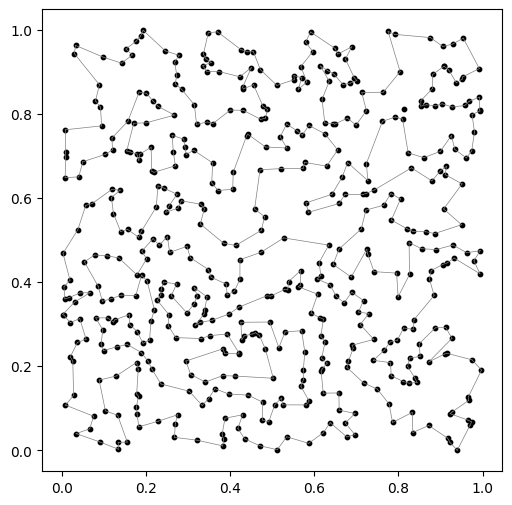

(<Figure size 600x600 with 1 Axes>, <Axes: >)

In [ ]:
draw_both(I, best_ils)

### Variante com critério de aceitação

Uma busca local iterada com o critério de Metropolis de aceitação.

In [ ]:
def ils_accept(I, s, T):
    """Busca local iterada com critério de aceitação Metropolis."""
    best = s.copy()
    s = bl_2ex(I, s)
    i = ii = 1
    print(f"I {i:3} {i - ii:>2} {s.v:.3f} {best.v:.3f}")

    while i - ii < 100:
        i += 1
        s0 = s.copy()
        s = move_double_bridge(I, s, random_double_bridge(I.n))
        s = bl_2ex(I, s)

        if s.v < best.v:
            best = s.copy()
            ii = i
            print(f"* {i:3} {i - ii:>2} {s.v:.3f} {best.v:.3f}")
        elif s.v < s0.v or np.random.rand() > min(np.exp(-(s.v - s0.v) / T), 1.0):
            print(f"A {i:3} {i - ii:>2} {s.v:.3f} {best.v:.3f}")
            s = s0.copy()
        else:
            print(f"R {i:3} {i - ii:>2} {s.v:.3f} {best.v:.3f}")

    return best

In [ ]:
best_ils_accept = ils_accept(I, vmp(I).copy(), 1)

I   1  0 17.767 20.744
*   2  0 17.979 17.979
R   3  1 18.481 17.979
R   4  2 18.587 17.979
A   5  3 19.216 17.979
R   6  4 18.704 17.979
R   7  5 18.944 17.979
R   8  6 18.955 17.979
R   9  7 19.001 17.979
R  10  8 19.017 17.979
A  11  9 18.734 17.979
A  12 10 18.860 17.979
A  13 11 19.015 17.979
R  14 12 19.092 17.979
R  15 13 19.155 17.979
A  16 14 19.077 17.979
R  17 15 19.165 17.979
A  18 16 19.080 17.979
A  19 17 18.900 17.979
A  20 18 18.776 17.979
A  21 19 19.162 17.979
A  22 20 18.945 17.979
A  23 21 18.937 17.979
R  24 22 19.434 17.979
A  25 23 18.999 17.979
R  26 24 19.487 17.979
A  27 25 19.249 17.979
A  28 26 19.202 17.979
R  29 27 19.592 17.979
A  30 28 19.405 17.979
A  31 29 19.761 17.979
A  32 30 18.967 17.979
A  33 31 19.194 17.979
A  34 32 19.427 17.979
A  35 33 19.556 17.979
R  36 34 19.897 17.979
A  37 35 19.485 17.979
A  38 36 19.340 17.979
A  39 37 19.749 17.979
A  40 38 19.588 17.979
A  41 39 19.529 17.979
R  42 40 20.056 17.979
A  43 41 19.829 17.979
A  44 42 19

In [ ]:
draw_both(I, best_ils_accept)

NameError: name 'best_ils_accept' is not defined